# Notebook 11 — LDA (Gensim) vs SBERT semantic clusters (2019–2021)

**All logic runs in this notebook.**

**Input:** `data/abcnews-date-text 2.csv` → filtered **2019–2021** → `data/df_clean.pkl`

**Deep-learning side (replaces BERTopic):** `sentence-transformers` **all-MiniLM-L6-v2** → **UMAP** (5D) → **HDBSCAN** (same hyperparameters as the old BERTopic block). Topic words = **TF-IDF** on `clean_text` per cluster.

**Outputs:**
- `models/sbert_topic_bundle.joblib` — labels + per-cluster TF-IDF terms (+ model name)
- `reports/topic_modeling/topics_over_time.csv`
- `reports/topic_modeling/lda_k_selection_metrics.csv` & `lda_k_metrics_sweep.png` (C_V, U_Mass, diversity, perplexity)
- `reports/topic_modeling/lda_vs_sbert_comparison.csv`
- `reports/topic_modeling/lda_vs_sbert_theme_keywords.csv`
- Plotly HTML: `sbert_intertopic.html`, `sbert_topics_over_time.html`

**Kernel:** Python **3.11** with `gensim`, `sentence-transformers`, `umap-learn`, `hdbscan`, `scikit-learn`, `plotly`.


## Configuration

Set `MAX_DOCS` below:
- `None` — full corpus (~92k headlines; long on CPU)
- e.g. `5000` — quick smoke test


In [1]:
import os
import re
import time
import warnings
from typing import Dict, List, Tuple

import joblib
import numpy as np
import pandas as pd

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
PROJECT_ROOT = os.getcwd()
print("CWD:", PROJECT_ROOT)

import matplotlib.pyplot as plt
from gensim import corpora, models
from gensim.models import CoherenceModel

warnings.filterwarnings("ignore", category=UserWarning)

OUT_DIR = "reports/topic_modeling"
MODEL_DIR = "models"
PKL_PATH = "data/df_clean.pkl"
DATA_CSV = "data/abcnews-date-text 2.csv"
K_SWEEP = [5, 10, 15, 20, 25]
LDA_FIXED_K = 10
LDA_PASSES = 10
LDA_HOLDOUT_FRACTION = 0.1
LDA_TOPN_DIVERSITY = 10
LDA_MIN_DOCS_FOR_HOLDOUT = 30
YEAR_MIN, YEAR_MAX = 2019, 2021

MAX_DOCS = None  # e.g. 5000 for a fast test; None = full ~92k corpus

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs("data", exist_ok=True)


CWD: /Users/kk/ai_dl_project/dynamic-trend-event-detector


## Step 1 — Build `df_clean.pkl` (2019–2021)


In [2]:
def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\b\w{1,2}\b", " ", text)
    return re.sub(r"\s+", " ", text).strip()

df = pd.read_csv(DATA_CSV)
df["publish_date"] = pd.to_datetime(df["publish_date"].astype(str), format="%Y%m%d")
df["headline_text"] = df["headline_text"].astype(str)
df["clean_text"] = df["headline_text"].apply(clean_text)
df = df[(df["publish_date"].dt.year >= YEAR_MIN) & (df["publish_date"].dt.year <= YEAR_MAX)]
df = df[df["clean_text"].str.len() > 5].reset_index(drop=True)
df.to_pickle(PKL_PATH)
print(f"Saved {len(df):,} rows → {PKL_PATH}")
print(f"  Date range: {df['publish_date'].min().date()} → {df['publish_date'].max().date()}")

if MAX_DOCS is not None:
    df = df.sample(min(MAX_DOCS, len(df)), random_state=42).reset_index(drop=True)
    print(f"[subsample] Using {len(df):,} documents")
else:
    print(f"Using full corpus: {len(df):,} documents")

docs = df["clean_text"].tolist()
headlines = df["headline_text"].tolist()
timestamps = df["publish_date"].dt.strftime("%Y-%m-%d").tolist()


Saved 92,191 rows → data/df_clean.pkl
  Date range: 2019-01-01 → 2021-12-31
Using full corpus: 92,191 documents


## Step 2 — Helper functions (LDA + SBERT tables)


In [3]:
import math
from sklearn.model_selection import train_test_split

def tokenize(text: str) -> List[str]:
    return [t for t in text.split() if len(t) > 2]


def lda_topic_word_diversity(lda_model, topn: int = 10) -> float:
    """Share of distinct words among K * topn top-word slots (higher => less overlap)."""
    seen = set()
    nslots = 0
    for i in range(lda_model.num_topics):
        for w, _ in lda_model.show_topic(i, topn=topn):
            seen.add(w)
            nslots += 1
    return len(seen) / max(nslots, 1)


def _train_test_texts_corpus(texts, corpus, random_state: int):
    n = len(corpus)
    if n < LDA_MIN_DOCS_FOR_HOLDOUT:
        return texts, texts, corpus, corpus, False
    idx = np.arange(n)
    tr, te = train_test_split(idx, test_size=LDA_HOLDOUT_FRACTION, random_state=random_state)
    train_texts = [texts[i] for i in tr]
    test_texts = [texts[i] for i in te]
    train_corpus = [corpus[i] for i in tr]
    test_corpus = [corpus[i] for i in te]
    return train_texts, test_texts, train_corpus, test_corpus, True


def run_lda_sweep(texts, dictionary, corpus, random_state: int = 42):
    """C_V, U_Mass, topic diversity, held-out perplexity; refit best K on full corpus."""
    np.random.seed(random_state)
    train_texts, test_texts, train_corpus, test_corpus, holdout_ok = _train_test_texts_corpus(
        texts, corpus, random_state
    )
    rows = []
    best_c_v, best_k = -1.0, K_SWEEP[0]

    for k in K_SWEEP:
        t0 = time.perf_counter()
        lda_k = models.LdaModel(
            corpus=train_corpus,
            id2word=dictionary,
            num_topics=k,
            passes=LDA_PASSES,
            random_state=random_state,
            alpha="auto",
        )
        c_v = CoherenceModel(
            model=lda_k, texts=train_texts, dictionary=dictionary, coherence="c_v"
        ).get_coherence()
        u_mass = CoherenceModel(
            model=lda_k, texts=train_texts, dictionary=dictionary, coherence="u_mass"
        ).get_coherence()
        div = lda_topic_word_diversity(lda_k, topn=LDA_TOPN_DIVERSITY)
        if holdout_ok and len(test_corpus) > 0:
            perp = math.exp(-lda_k.log_perplexity(test_corpus))
            perp_note = "held-out"
        else:
            perp = math.exp(-lda_k.log_perplexity(train_corpus))
            perp_note = "in-sample (corpus small for holdout)"
        elapsed = time.perf_counter() - t0
        rows.append(
            {
                "k": k,
                "c_v": c_v,
                "u_mass": u_mass,
                "topic_word_diversity": div,
                "perplexity_exp_neg_log_p": perp,
                "perplexity_split": perp_note,
                "train_secs": round(elapsed, 1),
            }
        )
        print(
            f"  K={k:2d}  C_V={c_v:.4f}  U_mass={u_mass:.4f}  div={div:.3f}  perp={perp:.2f}  ({elapsed:.1f}s)"
        )
        if c_v > best_c_v:
            best_c_v, best_k = c_v, k

    metrics_df = pd.DataFrame(rows)
    print(f"\n► Best K by C_V: {best_k} (C_V={best_c_v:.4f})")
    if holdout_ok:
        k_perp = int(metrics_df.loc[metrics_df["perplexity_exp_neg_log_p"].idxmin(), "k"])
        print(
            f"► Best K by lowest held-out perplexity: {k_perp} (min perp={metrics_df['perplexity_exp_neg_log_p'].min():.2f})"
        )

    lda_best = models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=best_k,
        passes=LDA_PASSES,
        random_state=random_state,
        alpha="auto",
    )
    return list(K_SWEEP), metrics_df, lda_best


def run_lda_fixed(corpus, dictionary, texts, num_topics=LDA_FIXED_K, passes=LDA_PASSES, random_state=42):
    t0 = time.perf_counter()
    lda = models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        passes=passes,
        random_state=random_state,
        alpha="auto",
    )
    train_s = time.perf_counter() - t0
    cm = CoherenceModel(model=lda, texts=texts, dictionary=dictionary, coherence="c_v")
    return lda, cm.get_coherence(), train_s


def build_cluster_tfidf_topics(
    docs: List[str], labels: np.ndarray, topn: int = 25
) -> Dict[int, List[Tuple[str, float]]]:
    from sklearn.feature_extraction.text import TfidfVectorizer

    out: Dict[int, List[Tuple[str, float]]] = {}
    for tid in sorted(set(labels.tolist())):
        if tid == -1:
            continue
        mask = labels == tid
        sub = [docs[i] for i in range(len(docs)) if mask[i]]
        if len(sub) < 2:
            continue
        vec = TfidfVectorizer(
            max_features=8000,
            min_df=2,
            max_df=0.95,
            stop_words="english",
        )
        try:
            X = vec.fit_transform(sub)
        except ValueError:
            continue
        scores = np.asarray(X.sum(axis=0)).ravel()
        terms = np.array(vec.get_feature_names_out())
        idx = np.argsort(scores)[::-1][:topn]
        out[int(tid)] = [(terms[i], float(scores[i])) for i in idx]
    return out


def sbert_cluster_coherence(
    cluster_topics: Dict[int, List[Tuple[str, float]]], texts, dictionary
) -> float:
    tw: List[List[str]] = []
    for tid in sorted(cluster_topics.keys()):
        tw.append([w for w, _ in cluster_topics[tid][:20]])
    if len(tw) < 2:
        return float("nan")
    cm = CoherenceModel(topics=tw, texts=texts, dictionary=dictionary, coherence="c_v")
    return cm.get_coherence()


def keyword_theme_table_sbert(
    lda,
    cluster_topics: Dict[int, List[Tuple[str, float]]],
    lda_k: int,
    keywords: List[str],
    sbert_topic_ids: List[int],
) -> pd.DataFrame:
    rows = []
    for kw in keywords:
        lda_hit = None
        for i in range(lda_k):
            words = [w.lower() for w, _ in lda.show_topic(i, topn=30)]
            if any(kw in w or w in kw for w in words):
                lda_hit = i
                break
        sb_hit = None
        for tid in sbert_topic_ids:
            if tid == -1 or tid not in cluster_topics:
                continue
            words = [w.lower() for w, _ in cluster_topics[tid]]
            if any(kw in w for w in words):
                sb_hit = tid
                break
        lda_words = (
            ", ".join([w for w, _ in lda.show_topic(lda_hit, topn=12)])
            if lda_hit is not None
            else ""
        )
        sb_words = (
            ", ".join([w for w, _ in cluster_topics[sb_hit][:12]])
            if sb_hit is not None
            else ""
        )
        rows.append(
            {
                "keyword_theme": kw,
                "lda_topic_id": lda_hit,
                "lda_top_words": lda_words,
                "sbert_topic_id": sb_hit,
                "sbert_top_words": sb_words,
            }
        )
    return pd.DataFrame(rows)


## Step 3A — Tokenize, Dictionary, Corpus, LDA **multi-metric** sweep + K=10 reference

K sweep reports **C_V**, **U_Mass**, **topic word diversity**, and **held-out perplexity** (`exp(−log_perplexity)` — lower is better). Table: `lda_k_selection_metrics.csv`; figure: `lda_k_metrics_sweep.png`. Best **saved** model is still chosen by **max C_V**; the table shows when another metric disagrees.

**Two different LDA runs on purpose**

- **`K_SWEEP`** (default `[5, 10, 15, 20, 25]`): train one model per K, pick **best C_V coherence** in that grid. The winning model is saved as `lda_model_k{best_k}.gensim` (e.g. K=25 if that scores highest).
- **`LDA_FIXED_K = 10`**: a second, **fixed** LDA trained only so you have a **compact reference** (readable top words, stable tables in “LDA vs SBERT” comparisons). This is **not** forced to match the sweep winner — it is a deliberate **interpretability / reporting** choice.

**Can you sweep higher K (e.g. 30–80)?** Yes — edit `K_SWEEP` in the config cell. C_V **often keeps rising** for a while because more topics can mean **narrower, more coherent word sets** — but very large K yields **fragmented** topics, harder labels, longer training, and coherence alone does not prove the topics are **useful**. Prefer an **elbow / plateau**, held-out perplexity, or manual reading of top words — not only “maximize C_V forever.”



=== LDA multi-metric K sweep (K in [5, 10, 15, 20, 25]) ===



  K= 5  C_V=0.3378  U_mass=-6.2044  div=0.980  perp=12574.65  (31.1s)


  K=10  C_V=0.3665  U_mass=-9.1373  div=1.000  perp=23357.63  (30.7s)


  K=15  C_V=0.3518  U_mass=-9.8775  div=1.000  perp=252555.84  (31.6s)


  K=20  C_V=0.3907  U_mass=-11.4336  div=1.000  perp=763815.74  (32.8s)


  K=25  C_V=0.4148  U_mass=-12.3981  div=0.996  perp=2281610.55  (34.4s)

► Best K by C_V: 25 (C_V=0.4148)
► Best K by lowest held-out perplexity: 5 (min perp=12574.65)


Saved → reports/topic_modeling/lda_k_selection_metrics.csv


,k,c_v,u_mass,topic_word_diversity,perplexity_exp_neg_log_p,perplexity_split,train_secs
0,5,0.337784,-6.204365,0.980,1.257465e+04,held-out,31.1
1,10,0.366487,-9.137251,1.000,2.335763e+04,held-out,30.7
2,15,0.351803,-9.877477,1.000,2.525558e+05,held-out,31.6
3,20,0.390657,-11.433623,1.000,7.638157e+05,held-out,32.8
4,25,0.414773,-12.398101,0.996,2.281611e+06,held-out,34.4


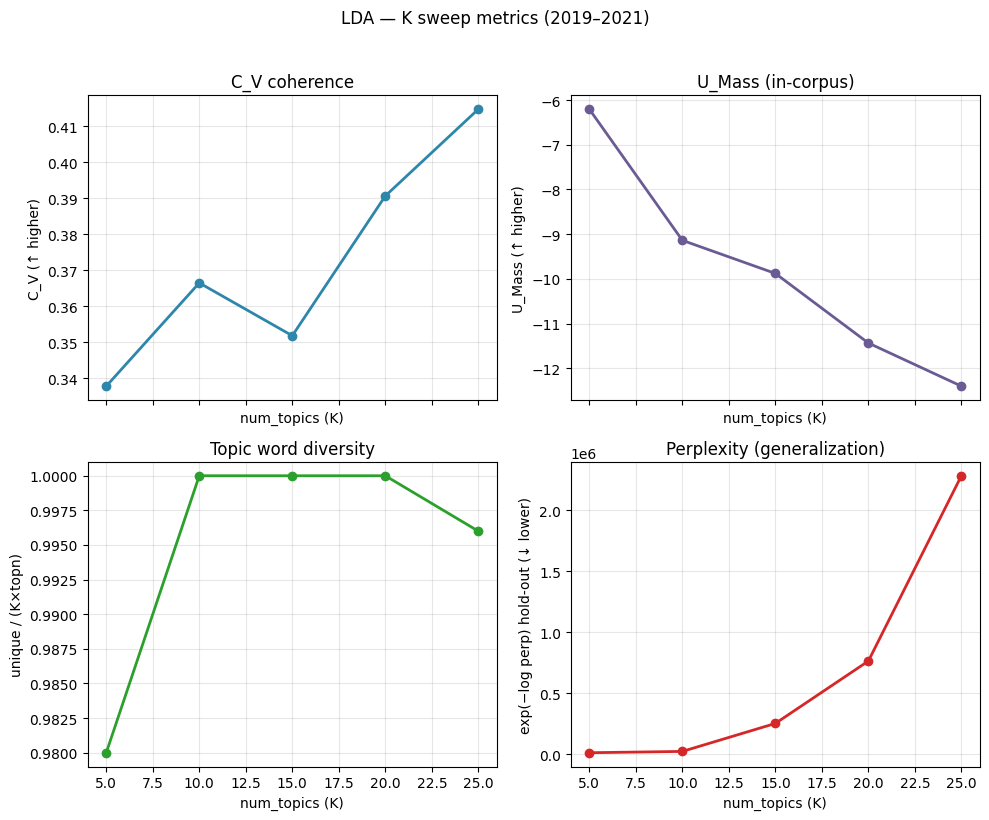

Saved → reports/topic_modeling/lda_k_metrics_sweep.png

=== LDA reference: K=10, passes=10 ===



  LDA (K=10) C_V = 0.3274  |  train time = 25.9s


In [4]:
try:
    from IPython.display import display
except ImportError:
    display = print

texts = [tokenize(d) for d in docs]
dictionary = corpora.Dictionary(texts)
dictionary.filter_extremes(no_below=3, no_above=0.55)
corpus = [dictionary.doc2bow(t) for t in texts]

print("\n=== LDA multi-metric K sweep (K in %s) ===\n" % K_SWEEP)
ks, metrics_df, lda_best = run_lda_sweep(texts, dictionary, corpus)

m_path = os.path.join(OUT_DIR, "lda_k_selection_metrics.csv")
metrics_df.to_csv(m_path, index=False)
print("Saved →", m_path)
display(metrics_df)

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
axes[0, 0].plot(metrics_df["k"], metrics_df["c_v"], "o-", color="#2E86AB", linewidth=2)
axes[0, 0].set_ylabel("C_V (↑ higher)")
axes[0, 0].set_title("C_V coherence")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(metrics_df["k"], metrics_df["u_mass"], "o-", color="#6B5B95", linewidth=2)
axes[0, 1].set_ylabel("U_Mass (↑ higher)")
axes[0, 1].set_title("U_Mass (in-corpus)")
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(metrics_df["k"], metrics_df["topic_word_diversity"], "o-", color="#2ca02c", linewidth=2)
axes[1, 0].set_ylabel("unique / (K×topn)")
axes[1, 0].set_title("Topic word diversity")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(metrics_df["k"], metrics_df["perplexity_exp_neg_log_p"], "o-", color="#d62728", linewidth=2)
axes[1, 1].set_ylabel("exp(−log perp) hold-out (↓ lower)")
axes[1, 1].set_title("Perplexity (generalization)")
axes[1, 1].grid(True, alpha=0.3)

for ax in axes.ravel():
    ax.set_xlabel("num_topics (K)")
plt.suptitle("LDA — K sweep metrics (2019–2021)", y=1.02)
plt.tight_layout()
p_sweep = os.path.join(OUT_DIR, "lda_k_metrics_sweep.png")
plt.savefig(p_sweep, dpi=150)
plt.show()
print("Saved →", p_sweep)

best_k = int(metrics_df.loc[metrics_df["c_v"].idxmax(), "k"])
lda_best.save(os.path.join(OUT_DIR, f"lda_model_k{best_k}.gensim"))

print("\n=== LDA reference: K=10, passes=%d ===\n" % LDA_PASSES)
lda10, coh10, t_lda = run_lda_fixed(corpus, dictionary, texts)
print(f"  LDA (K=10) C_V = {coh10:.4f}  |  train time = {t_lda:.1f}s")
lda10.save(os.path.join(OUT_DIR, "lda_model_k10.gensim"))


## Step 3B — SBERT + UMAP + HDBSCAN, `topics_over_time`, visuals, tables


In [5]:
from sentence_transformers import SentenceTransformer
from hdbscan import HDBSCAN
from umap import UMAP
import plotly.graph_objects as go

print("Loading SBERT (all-MiniLM-L6-v2) …")
sbert = SentenceTransformer("all-MiniLM-L6-v2")

t_enc0 = time.perf_counter()
embeddings = sbert.encode(
    headlines,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True,
)
embeddings = np.asarray(embeddings)
t_encode = time.perf_counter() - t_enc0
print(f"SBERT encode time: {t_encode:.1f}s  |  shape {embeddings.shape}")

umap_model = UMAP(
    n_components=5,
    n_neighbors=15,
    min_dist=0.0,
    metric="cosine",
    random_state=42,
)
reduced = umap_model.fit_transform(embeddings)

hdbscan_model = HDBSCAN(
    min_cluster_size=20,
    metric="euclidean",
    prediction_data=True,
)

t_cl0 = time.perf_counter()
topics = hdbscan_model.fit_predict(reduced)
t_cluster = time.perf_counter() - t_cl0
print(f"UMAP+HDBSCAN fit time: {t_cluster:.1f}s")

cluster_topics = build_cluster_tfidf_topics(docs, topics, topn=25)
coh_sb = sbert_cluster_coherence(cluster_topics, texts, dictionary)
print(f"SBERT-cluster TF-IDF words — aggregate C_V: {coh_sb:.4f}")

bundle = {
    "sentence_model_name": "all-MiniLM-L6-v2",
    "topic_labels": topics,
    "cluster_topics_tfidf": cluster_topics,
    "embeddings_shape": embeddings.shape,
}
joblib.dump(bundle, os.path.join(MODEL_DIR, "sbert_topic_bundle.joblib"))
print("Saved →", os.path.join(MODEL_DIR, "sbert_topic_bundle.joblib"))

# --- topics_over_time: 40 quantile bins on publish_date, row-wise topic proportions ---
df_t = df.copy()
df_t["topic_id"] = topics
df_t["publish_date"] = pd.to_datetime(df_t["publish_date"])
bins = pd.qcut(df_t["publish_date"], q=40, duplicates="drop")
df_t["time_bin"] = bins
counts = (
    df_t.groupby(["time_bin", "topic_id"], observed=True)
    .size()
    .unstack(fill_value=0)
)
row_sum = counts.sum(axis=1).replace(0, np.nan)
prop = counts.div(row_sum, axis=0)
topics_time = prop.reset_index().melt(
    id_vars=["time_bin"], var_name="topic_id", value_name="proportion"
)
topics_time["bin_start"] = topics_time["time_bin"].apply(lambda x: x.left)
topics_time["bin_end"] = topics_time["time_bin"].apply(lambda x: x.right)
topics_time["bin_mid"] = topics_time["time_bin"].apply(lambda x: x.mid)
p_tot = os.path.join(OUT_DIR, "topics_over_time.csv")
topics_time.to_csv(p_tot, index=False)
print(f"Saved → {p_tot}  ({len(topics_time)} rows)")

# --- Plotly: SBERT cluster centroids in embedding space, UMAP-2D for inter-topic map ---
sb_ids = sorted({int(t) for t in topics if t != -1})
centroids = []
for tid in sb_ids:
    mask = topics == tid
    centroids.append(embeddings[mask].mean(axis=0))
centroids = np.asarray(centroids)
cent_2d = UMAP(
    n_components=2,
    n_neighbors=min(15, len(centroids) - 1) if len(centroids) > 2 else 2,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
).fit_transform(centroids)

fig_it = go.Figure(
    data=[
        go.Scatter(
            x=cent_2d[:, 0],
            y=cent_2d[:, 1],
            mode="markers+text",
            text=[f"T{t}" for t in sb_ids],
            textposition="top center",
            marker=dict(size=14, color=sb_ids, colorscale="Viridis", showscale=True),
        )
    ]
)
fig_it.update_layout(
    title="SBERT + HDBSCAN — topic centroids (UMAP-2D of mean embeddings)",
    xaxis_title="UMAP-1",
    yaxis_title="UMAP-2",
    height=520,
)
p_html1 = os.path.join(OUT_DIR, "sbert_intertopic.html")
fig_it.write_html(p_html1)
print("Saved →", p_html1)

# --- Plotly: topic prevalence over time (top 8 clusters by volume) ---
vc = pd.Series(topics).value_counts()
top8 = [t for t in vc.index.tolist() if t != -1][:8]
bin_mid = [ival.mid for ival in prop.index]
fig_ot = go.Figure()
for tid in top8:
    if tid not in prop.columns:
        continue
    fig_ot.add_trace(
        go.Scatter(
            x=bin_mid,
            y=prop[tid].values,
            mode="lines",
            name=f"Topic {tid}",
        )
    )
fig_ot.update_layout(
    title="SBERT clusters — topic proportion over time (40 bins)",
    xaxis_title="Date (bin centre)",
    yaxis_title="Proportion within bin",
    height=520,
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
)
p_html2 = os.path.join(OUT_DIR, "sbert_topics_over_time.html")
fig_ot.write_html(p_html2)
print("Saved →", p_html2)

rows_side = []
for i in range(LDA_FIXED_K):
    lda_w = ", ".join([w for w, _ in lda10.show_topic(i, topn=10)])
    rows_side.append({"model": "LDA", "topic_id": i, "top_words": lda_w})
for tid in sb_ids:
    cw = cluster_topics.get(tid, [])
    bw = ", ".join([w for w, _ in cw[:10]])
    rows_side.append({"model": "SBERT+HDBSCAN", "topic_id": tid, "top_words": bw})
side = pd.DataFrame(rows_side)
side.to_csv(os.path.join(OUT_DIR, "lda_vs_sbert_topwords_long.csv"), index=False)

theme_kw = [
    "bushfire",
    "fire",
    "covid",
    "coronavirus",
    "climate",
    "police",
    "election",
]
kw_df = keyword_theme_table_sbert(
    lda10, cluster_topics, LDA_FIXED_K, theme_kw, sb_ids
)
kw_df.to_csv(os.path.join(OUT_DIR, "lda_vs_sbert_theme_keywords.csv"), index=False)

summary = pd.DataFrame(
    [
        {
            "metric": "LDA K=10 C_V (Gensim)",
            "value": f"{coh10:.4f}",
            "notes": f"passes={LDA_PASSES}, train_time_s={t_lda:.1f}",
        },
        {
            "metric": f"LDA best K sweep (K={best_k})",
            "value": f"{metrics_df['c_v'].max():.4f}",
            "notes": f"sweep K in {K_SWEEP}",
        },
        {
            "metric": "SBERT clusters C_V (TF-IDF words, same texts/dict)",
            "value": f"{coh_sb:.4f}",
            "notes": f"encode_s={t_encode:.1f}, umap_hdbscan_s={t_cluster:.1f}",
        },
        {
            "metric": "SBERT clusters (excl. -1 noise)",
            "value": str(len(sb_ids)),
            "notes": "HDBSCAN min_cluster_size=20",
        },
    ]
)
summary.to_csv(os.path.join(OUT_DIR, "lda_vs_sbert_comparison.csv"), index=False)
print("\n=== Summary ===\n")
print(summary.to_string(index=False))
print("\nKey deliverable:", os.path.join(OUT_DIR, "lda_vs_sbert_theme_keywords.csv"))


Loading SBERT (all-MiniLM-L6-v2) …


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1441 [00:00<?, ?it/s]

SBERT encode time: 32.4s  |  shape (92191, 384)


UMAP+HDBSCAN fit time: 4.6s


SBERT-cluster TF-IDF words — aggregate C_V: 0.3648
Saved → models/sbert_topic_bundle.joblib


Saved → reports/topic_modeling/topics_over_time.csv  (25480 rows)


Saved → reports/topic_modeling/sbert_intertopic.html
Saved → reports/topic_modeling/sbert_topics_over_time.html

=== Summary ===

                                            metric  value                             notes
                             LDA K=10 C_V (Gensim) 0.3274      passes=10, train_time_s=25.9
                           LDA best K sweep (K=25) 0.4148    sweep K in [5, 10, 15, 20, 25]
SBERT clusters C_V (TF-IDF words, same texts/dict) 0.3648 encode_s=32.4, umap_hdbscan_s=4.6
                   SBERT clusters (excl. -1 noise)    636       HDBSCAN min_cluster_size=20

Key deliverable: reports/topic_modeling/lda_vs_sbert_theme_keywords.csv


## Step 4 — Load comparison tables


In [6]:
from pathlib import Path

try:
    from IPython.display import display
except ImportError:
    display = print

base = Path(OUT_DIR)
for name in ["lda_vs_sbert_comparison.csv", "lda_vs_sbert_theme_keywords.csv"]:
    p = base / name
    if p.exists():
        print(f"\n=== {name} ===")
        display(pd.read_csv(p))
    else:
        print("Missing:", p)



=== lda_vs_sbert_comparison.csv ===


,metric,value,notes
0,LDA K=10 C_V (Gensim),0.3274,"passes=10, train_time_s=25.9"
1,LDA best K sweep (K=25),0.4148,"sweep K in [5, 10, 15, 20, 25]"
2,"SBERT clusters C_V (TF-IDF words, same texts/d...",0.3648,"encode_s=32.4, umap_hdbscan_s=4.6"
3,SBERT clusters (excl. -1 noise),636.0000,HDBSCAN min_cluster_size=20



=== lda_vs_sbert_theme_keywords.csv ===


,keyword_theme,lda_topic_id,lda_top_words,sbert_topic_id,sbert_top_words
0,bushfire,2,"after, victoria, health, south, two, people, y...",66,"koala, koalas, nsw, bushfires, habitat, bushfi..."
1,fire,2,"after, victoria, health, south, two, people, y...",35,"nagorno, karabakh, armenia, azerbaijan, ceasef..."
2,covid,7,"covid, new, coronavirus, australia, says, quee...",32,"briggs, casey, covid, looks, analyst, chant, k..."
3,coronavirus,7,"covid, new, coronavirus, australia, says, quee...",32,"briggs, casey, covid, looks, analyst, chant, k..."
4,climate,6,"nsw, lockdown, under, open, victorian, residen...",67,"thunberg, greta, climate, david, attenborough,..."
5,police,9,"police, has, off, found, its, numbers, been, r...",38,"sydney, covid, parade, pride, police, sydneys,..."
6,election,3,"government, minister, scott, news, morrison, e...",44,"gladys, berejiklian, nsw, premier, icac, says,..."


## Spikes — use notebook 12 only

This notebook ends after **`topics_over_time.csv`** (and comparison tables). **Do not duplicate spike detection here.** Run **`12_phase4_trend_and_events.ipynb`** next to write **`spike_events.csv`** and optional anchor CSVs — same logic as `python src/spike_events_from_topics_over_time.py`.
